In [33]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [34]:
!export KAGGLE_API_TOKEN=KGAT_1e8712bdeb491d3a4b015f02d8948ff3

In [35]:
!mkdir -p ~/.kaggle && echo KGAT_1e8712bdeb491d3a4b015f02d8948ff3 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [36]:
!kaggle datasets download -d samuelcortinhas/apples-or-tomatoes-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification
License(s): CC0-1.0
apples-or-tomatoes-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [37]:
!unzip /content/apples-or-tomatoes-image-classification.zip

Archive:  /content/apples-or-tomatoes-image-classification.zip
replace test/apples/img_p1_111.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/apples/img_p1_121.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/apples/img_p1_127.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/apples/img_p1_131.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/apples/img_p1_133.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/apples/img_p1_139.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/apples/img_p1_14.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/apples/img_p1_143.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: test/apples/img_p1_143.jpeg  
  inflating: test/apples/img_p1_15.jpeg  
  inflating: test/apples/img_p1_16.jpeg  
  inflating: test/apples/img_p1_29.jpeg  
  inflating: test/apples/img_p1_30.jpeg  
  inflating: test/apples/img_p1_33.jpeg  
  inflating: test/apples/img_p1_34.jpeg  
  inflating: test/apples/im

In [38]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from keras.layers import BatchNormalization, Dropout

In [39]:
# Load dataset (train data)
train_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/train",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)

# Load dataset (validation data)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/test",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)

Found 294 files belonging to 2 classes.
Found 97 files belonging to 2 classes.


In [40]:
# Normalize (all images will be same px)
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [41]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [43]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [44]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 69s 6s/step - accuracy: 0.5918 - loss: 9.2987 - val_accuracy: 0.5876 - val_loss: 0.7509
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 79s 6s/step - accuracy: 0.7143 - loss: 4.2197 - val_accuracy: 0.5670 - val_loss: 2.0078
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.7449 - loss: 4.2227 - val_accuracy: 0.5567 - val_loss: 4.4275
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.7959 - loss: 3.4110 - val_accuracy: 0.5773 - val_loss: 3.3215
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 62s 6s/step - accuracy: 0.8401 - loss: 1.9933 - val_accuracy: 0.5773 - val_loss: 3.2081
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 63s 6s/step - accuracy: 0.8503 - loss: 1.8000 - val_accuracy: 0.5773 - val_loss: 4.1562
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 91s 7s/step - accuracy: 0.9150 - loss: 0.9254 - val_accuracy: 0.5979 - val_loss: 3.7360
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 63s 6s/step - accuracy: 0.8571 - loss: 1.8125 - val_accuracy: 0.5567 - val_loss:

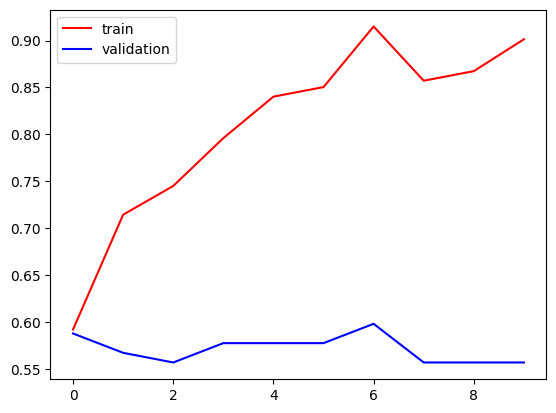

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

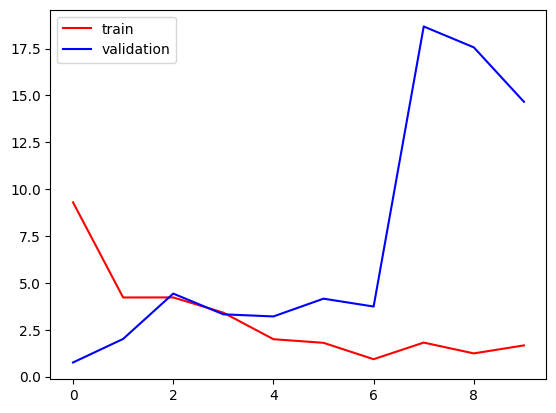

In [46]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
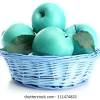

In [47]:
import cv2

test_img = cv2.imread("/content/test/apples/img_p2_13.jpeg")
test_img

In [48]:
test_img.shape

(100, 100, 3)

In [49]:
test_img = cv2.resize(test_img,(256,256))

In [50]:
test_img.shape

(256, 256, 3)

In [51]:
test_input = test_img.reshape((1,256,256,3))

In [52]:
test_input.shape

(1, 256, 256, 3)

In [53]:
result = model.predict(test_input)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


array([[4.899134e-14]], dtype=float32)

In [54]:
if int(result[0][0]) == 0:
  print("Apple")

else:
  print("Tomato")

Apple


# Handle the overfitting

In [55]:
# Re-initialize the model to apply changes cleanly
model_overfit_fixed = Sequential()

# Add Data Augmentation layers at the beginning
model_overfit_fixed.add(tf.keras.layers.RandomFlip("horizontal_and_vertical", input_shape=(256, 256, 3)))
model_overfit_fixed.add(tf.keras.layers.RandomRotation(0.2))

model_overfit_fixed.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model_overfit_fixed.add(BatchNormalization())
model_overfit_fixed.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model_overfit_fixed.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model_overfit_fixed.add(BatchNormalization())
model_overfit_fixed.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model_overfit_fixed.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model_overfit_fixed.add(BatchNormalization())
model_overfit_fixed.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model_overfit_fixed.add(Flatten())

model_overfit_fixed.add(Dense(128,activation='relu'))
model_overfit_fixed.add(Dropout(0.1))
model_overfit_fixed.add(Dense(64,activation='relu'))
model_overfit_fixed.add(Dropout(0.1))
model_overfit_fixed.add(Dense(1,activation='sigmoid'))

model_overfit_fixed.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [56]:
# Compile the modified model
model_overfit_fixed.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [57]:
from keras.callbacks import EarlyStopping

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model with early stopping
history_fixed = model_overfit_fixed.fit(
    train_ds,
    epochs=30, # Increased epochs, as early stopping will stop when appropriate
    validation_data=validation_ds,
    callbacks=[early_stopping] # Add the early stopping callback here
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 71s 7s/step - accuracy: 0.5850 - loss: 9.1756 - val_accuracy: 0.5567 - val_loss: 2.4458
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 79s 6s/step - accuracy: 0.6122 - loss: 7.0354 - val_accuracy: 0.5464 - val_loss: 1.6961
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 66s 7s/step - accuracy: 0.6293 - loss: 5.4599 - val_accuracy: 0.5464 - val_loss: 2.6755
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.7007 - loss: 3.1172 - val_accuracy: 0.5052 - val_loss: 2.5995
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.6633 - loss: 3.2789 - val_accuracy: 0.5773 - val_loss: 3.1452
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 66s 7s/step - accuracy: 0.6156 - loss: 4.7772 - val_accuracy: 0.7113 - val_loss: 1.7023
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - accuracy: 0.6837 - loss: 3.9975 - val_accuracy: 0.6392 - val_loss: 4.4749
